In [70]:
%load_ext autoreload
%autoreload 2


import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [71]:
import pandas as pd
from pathlib import Path

# Define the root directories
base_dirs = ['established', 'additional']

# List to hold all the individual DataFrames before concatenating
all_data = []

for base in base_dirs:
    base_path = Path('../../../sim_results/second_draft') / Path(base)
    
    if not base_path.exists():
        print(f"Directory '{base}' not found. Please ensure your notebook is in the correct root folder.")
        continue
        
    # rglob recursively searches for all CSVs ending in '_comprehensive_results.csv'
    for csv_file in base_path.rglob('*_comprehensive_results.csv'):
        
        # Dynamically determine metadata based on relative path parts
        # This safely handles both 3-layer and 4-layer deep folder structures
        relative_parts = csv_file.relative_to(base_path).parts
        
        community_config = relative_parts[0]  # Always the first folder after 'established'/'additional'
        sim_run = csv_file.parent.name         # Always the immediate parent folder of the CSV
        
        try:
            # Read the CSV
            df = pd.read_csv(csv_file)
            
            # Inject folder metadata as new columns
            df['experiment_group'] = base               # 'established' or 'additional'
            df['community_config'] = community_config   # 'ground_truth', 'tau_0', 'tau_2'
            df['sim_run'] = sim_run                     # Keep track of the specific run
            
            all_data.append(df)
            
        except Exception as e:
            print(f"Failed to read {csv_file.name}: {e}")

# Combine everything into one master DataFrame
if all_data:
    master_df = pd.concat(all_data, ignore_index=True)
    
    print("✅ Data successfully loaded and merged!")
    print(f"Total rows: {len(master_df)}")
    
    # Quick sanity check for the split 'additional' strategies
    contact_school_mask = (master_df['dataset'] == 'contact-primary-school') & \
                          (master_df['experiment_group'] == 'additional') & \
                          (master_df['community_config'] == 'ground_truth')
    
    strategies_found = master_df[contact_school_mask]['strategy'].nunique()
    print(f"Strategies found for 'contact-primary-school' (additional/ground_truth): {strategies_found}")
    
else:
    print("❌ No data was loaded. Please check the directory paths.")
    master_df = pd.DataFrame()

# Preview the assembled data
master_df.head()

✅ Data successfully loaded and merged!
Total rows: 23868
Strategies found for 'contact-primary-school' (additional/ground_truth): 8


,dataset,p,strategy,K,remaining_nodes,timestep,mean_infected,experiment_group,community_config,sim_run
0,Algebra,0.05,EPT_TS,21,402.0,0,1.000000,established,ground_truth,sim-results-sim_paper_1-27195582950
1,Algebra,0.05,EPT_TS,21,402.0,1,1.447761,established,ground_truth,sim-results-sim_paper_1-27195582950
2,Algebra,0.05,EPT_TS,21,402.0,2,1.763433,established,ground_truth,sim-results-sim_paper_1-27195582950
3,Algebra,0.05,EPT_TS,21,402.0,3,2.148010,established,ground_truth,sim-results-sim_paper_1-27195582950
4,Algebra,0.05,EPT_TS,21,402.0,4,2.629602,established,ground_truth,sim-results-sim_paper_1-27195582950


In [72]:
selected_df = master_df[master_df["strategy"].isin([
    'DEG',
    'HDEG',
    'EPT_BIS',
    'EPT_BOS',
    'EPT_TS',
    'aDEG',
    'aHDEG',
    'aEPT_BIS',
    'aEPT_BOS',
    'aEPT_TS',
    'RAND',
])
].copy()

selected_df.info()
set(selected_df.community_config)


<class 'pandas.DataFrame'>
Index: 15444 entries, 0 to 21059
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   dataset           15444 non-null  str    
 1   p                 15444 non-null  float64
 2   strategy          15444 non-null  str    
 3   K                 15444 non-null  int64  
 4   remaining_nodes   15444 non-null  float64
 5   timestep          15444 non-null  int64  
 6   mean_infected     15444 non-null  float64
 7   experiment_group  15444 non-null  str    
 8   community_config  15444 non-null  str    
 9   sim_run           15444 non-null  str    
dtypes: float64(3), int64(2), str(5)
memory usage: 1.3 MB


{'ground_truth', 'tau_0', 'tau_2'}

In [73]:
df = selected_df
set(df.dataset)

{'Algebra',
 'Bars-Rev',
 'Geometry',
 'Music-Rev',
 'Restaurants-Rev',
 'contact-primary-school'}

In [74]:
empty_sicp = Path("../../../sim_results/second_draft/empty_final_prevalence.csv")
empty_df = pd.read_csv(empty_sicp)
empty_df.head()

,Unnamed: 0,Algebra,Geometry,Restaurants-Rev,Music-Rev,Bars-Rev,contact-primary-school
0,Final Prevalence (\%),25.876856,69.739863,32.219908,76.637158,46.526246,1.003859


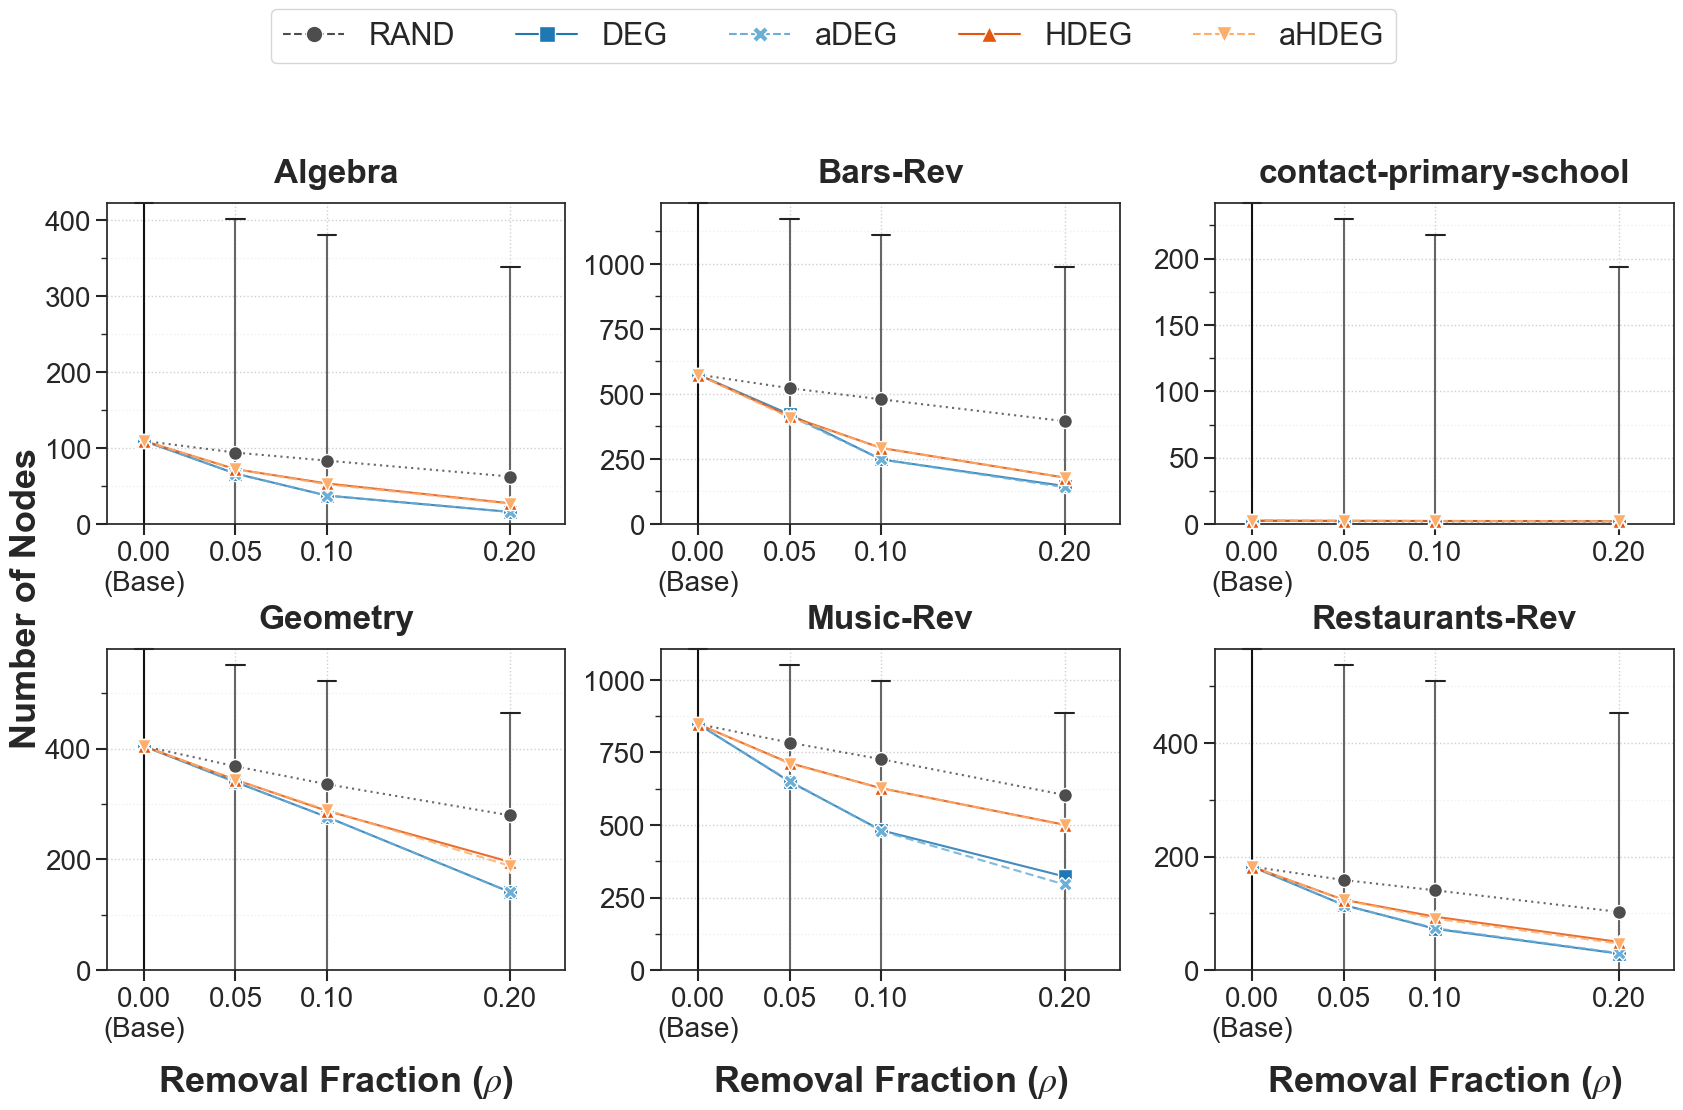

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.ticker import AutoMinorLocator

# ==========================================
# 1. Aesthetics (Reverted to default fonts)
# ==========================================
sns.set_theme(style="white") 

palette = {
    'RAND': '#4d4d4d', 'DEG': '#1f77b4', 'aDEG': '#6baed6', 'HDEG': '#e6550d', 'aHDEG': '#fdae6b'    
}

markers = {
    'RAND': 'o', 'DEG': 's', 'aDEG': 'X', 'HDEG': '^', 'aHDEG': 'v'
}

dashes = {
    'RAND': (1, 2), 'DEG': [], 'aDEG': (4, 2), 'HDEG': [], 'aHDEG': (4, 2)       
}

# ==========================================
# 2. Data Filtering & Baseline Integration
# ==========================================
local_strategies = ['RAND', 'DEG', 'aDEG', 'HDEG', 'aHDEG']

# Filter Section 5.1 data
plot_df = selected_df[
    (selected_df['community_config'] == 'ground_truth') &
    (selected_df['timestep'] == 25) &
    (selected_df['strategy'].isin(local_strategies))
].copy()

# Extract baseline percentages
baseline_pcts = empty_df.set_index('Unnamed: 0').iloc[0].to_dict()

dataset_max_capacities = {}
baseline_rows = []

for dataset, group in plot_df.groupby('dataset'):
    sample_row = group.iloc[0]
    # Reverse engineer original network capacity
    n0 = sample_row['remaining_nodes'] / (1 - sample_row['p'])
    dataset_max_capacities[dataset] = n0
    
    # Calculate absolute baseline infection
    pct = baseline_pcts.get(dataset, 0)
    abs_infected_base = n0 * (pct / 100.0)
    
    for strategy in local_strategies:
        baseline_rows.append({
            'dataset': dataset,
            'strategy': strategy,
            'p': 0.0,
            'remaining_nodes': n0,
            'mean_infected': abs_infected_base,
            'community_config': 'ground_truth',
            'timestep': 25
        })

# Combine into a single plotting dataframe
plot_df = pd.concat([plot_df, pd.DataFrame(baseline_rows)], ignore_index=True)

# ==========================================
# 3. Custom Drawing Function
# ==========================================
def draw_capacity_curves(data, **kwargs):
    ax = plt.gca()
    unique_ps = sorted(data['p'].unique())
    
    # Draw capacity trunks and T-caps
    for p_val in unique_ps:
        sub_data = data[data['p'] == p_val]
        if not sub_data.empty:
            rem_nodes = sub_data['remaining_nodes'].iloc[0]
            
            line_color = '#111111' if p_val == 0.0 else '#666666'
            
            ax.vlines(x=p_val, ymin=0, ymax=rem_nodes, colors=line_color, linewidth=1.5, zorder=1, clip_on=False)
            ax.plot([p_val - 0.005, p_val + 0.005], [rem_nodes, rem_nodes], color='#222222', linewidth=1.5, zorder=1, clip_on=False)
            
    # Draw trend lines and markers
    for strategy in local_strategies:
        strat_data = data[data['strategy'] == strategy].sort_values('p')
        if not strat_data.empty:
            dash_style = dashes.get(strategy, [])
            
            line, = ax.plot(
                strat_data['p'], strat_data['mean_infected'], 
                color=palette[strategy], linewidth=1.5, alpha=0.85, zorder=3, clip_on=False
            )
            if len(dash_style) > 0:
                line.set_dashes(dash_style)
                
            ax.scatter(
                strat_data['p'], strat_data['mean_infected'], 
                color=palette[strategy], marker=markers[strategy], s=100,
                edgecolor='white', linewidth=1.0, alpha=1.0, zorder=4, clip_on=False
            )

# ==========================================
# 4. Multi-Panel Layout & Formatting
# ==========================================
g = sns.FacetGrid(
    data=plot_df, col='dataset', col_wrap=3, height=5.2, aspect=1.1, sharey=False, sharex=False
)
g.map_dataframe(draw_capacity_curves)

# INCREASED FONT SIZES for Axis Labels and Titles
g.set_axis_labels("Removal Fraction ($\\rho$)", "", fontsize=26, weight='bold', labelpad=15)
g.set_titles(col_template="{col_name}", size=24, weight='bold', pad=15) 
g.fig.supylabel("Number of Nodes", fontsize=26, weight='bold')

# Axis Controls & Tick Fixes
for ax in g.axes.flat:
    current_title = ax.get_title()
    
    # Gridlines
    ax.grid(True, which='major', linestyle=':', alpha=0.6, color='#b0b0b0')
    ax.yaxis.set_minor_locator(AutoMinorLocator(2)) 
    ax.grid(True, which='minor', linestyle=':', alpha=0.3, color='#d0d0d0')
    
    # Spines
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    
    # Fix Ticks: Heavy major ticks, light minor ticks (INCREASED labelsize to 20)
    ax.tick_params(axis='both', which='major', labelsize=20, left=True, bottom=True, length=8, width=1.5)
    ax.tick_params(axis='y', which='minor', left=True, length=4, width=1.0) 
    
    # X-Axis limits and explicit ticks (INCREASED xticklabel fontsize to 20)
    ax.set_xticks([0.0, 0.05, 0.10, 0.20])
    ax.set_xticklabels(['0.00\n(Base)', '0.05', '0.10', '0.20'], fontsize=20)
    ax.set_xlim(-0.02, 0.23) 
    
    # Set exact ceiling
    if current_title in dataset_max_capacities:
        ax.set_ylim(bottom=0, top=dataset_max_capacities[current_title])
    else:
        ax.set_ylim(bottom=0)

# ==========================================
# 5. Legend Generation & Final Layout
# ==========================================
legend_handles = [
    plt.Line2D(
        [0], [0], marker=markers[s], color=palette[s], markerfacecolor=palette[s], 
        markeredgecolor='white', markeredgewidth=1.0, markersize=12, linewidth=1.5,
        linestyle='--' if len(dashes[s]) > 0 else '-', label=s
    ) for s in local_strategies
]

# INCREASED FONT SIZE for Legend (fontsize=22)
g.figure.legend(
    handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, 1.0),    
    ncol=5, frameon=True, fontsize=22, columnspacing=2.0
)

plt.tight_layout()
g.fig.subplots_adjust(top=0.88)   

plt.show()

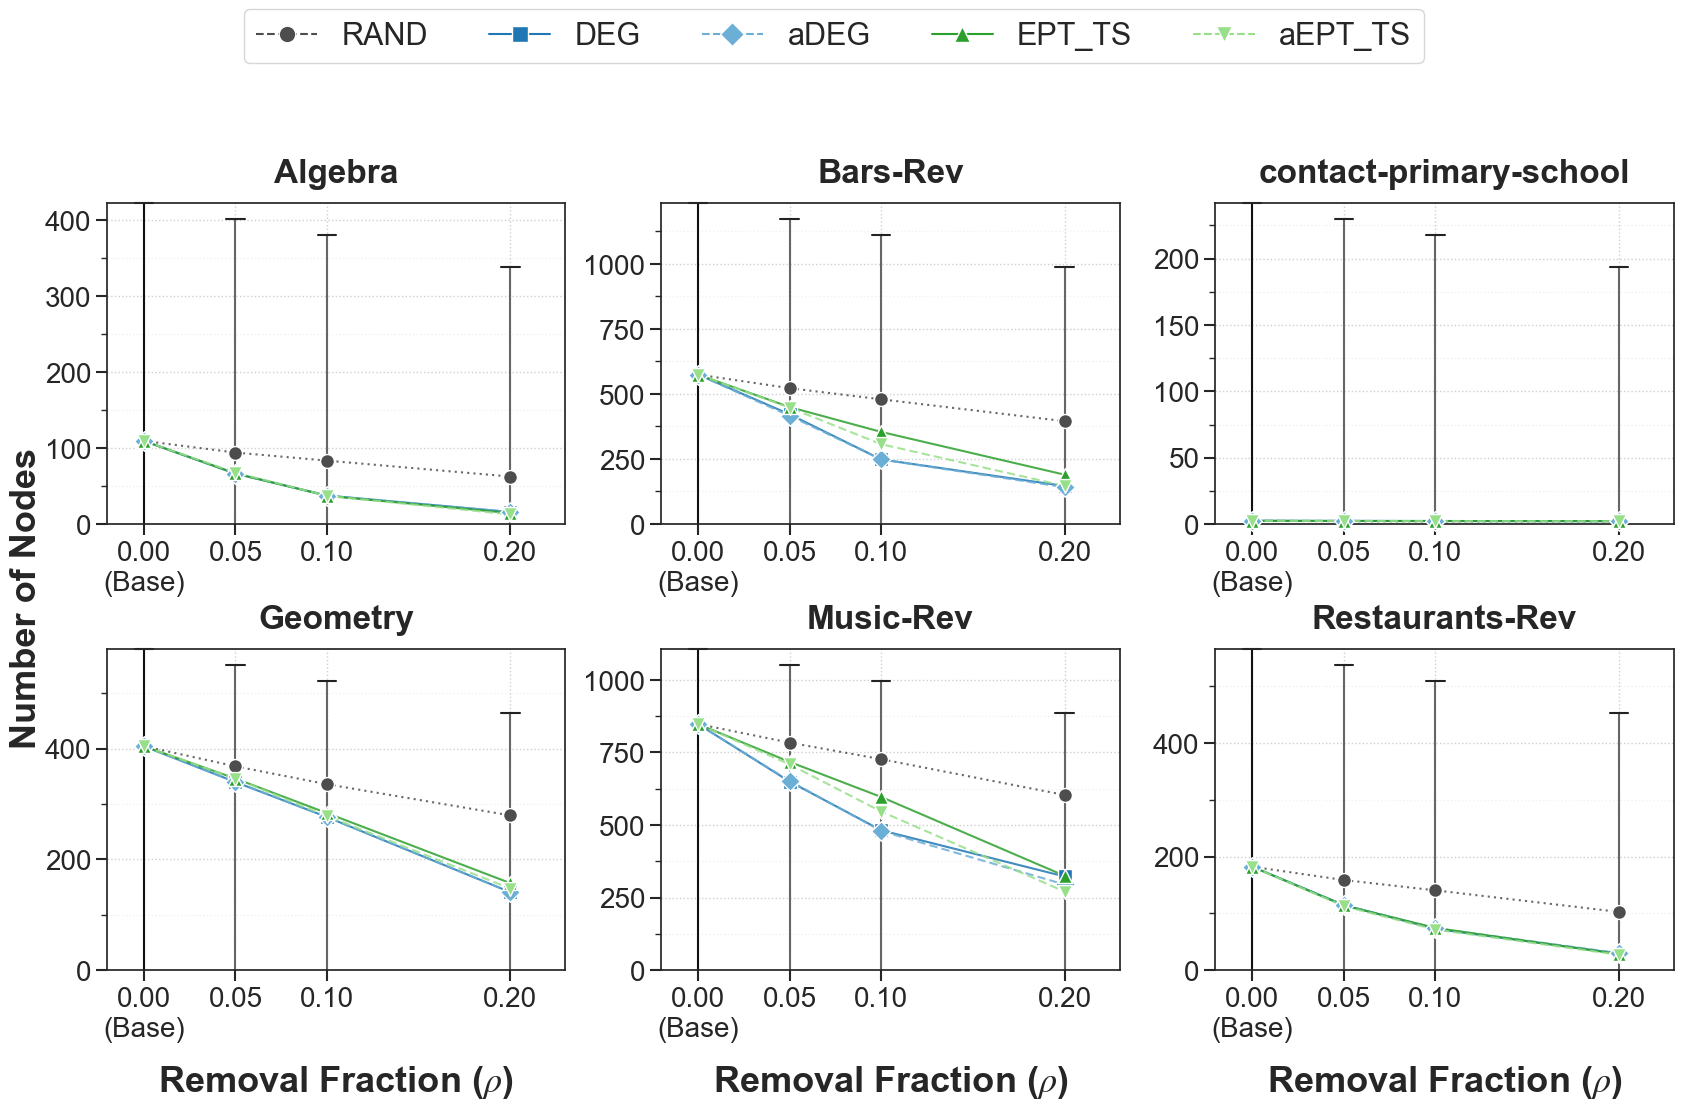

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.ticker import AutoMinorLocator

# ==========================================
# 1. Aesthetics (Default fonts with high visibility)
# ==========================================
sns.set_theme(style="white") 

# Updated palette, markers, and dashes to include all 5 strategies
palette = {
    'RAND': '#4d4d4d',    # Gray
    'DEG': '#1f77b4',     # Blue
    'aDEG': '#6baed6',    # Light Blue
    'EPT_TS': '#2ca02c',  # Dark Green
    'aEPT_TS': '#98df8a'  # Light Green
}

markers = {
    'RAND': 'o', 
    'DEG': 's', 
    'aDEG': 'D', 
    'EPT_TS': '^', 
    'aEPT_TS': 'v'
}

dashes = {
    'RAND': (1, 2), 
    'DEG': [], 
    'aDEG': (4, 2), 
    'EPT_TS': [], 
    'aEPT_TS': (4, 2)       
}

# ==========================================
# 2. Data Filtering & Baseline Integration
# ==========================================
# Full strategy list including aDEG
local_strategies = ['RAND', 'DEG', 'aDEG', 'EPT_TS', 'aEPT_TS']

# Filter Section 5.1 data
plot_df = selected_df[
    (selected_df['community_config'] == 'ground_truth') &
    (selected_df['timestep'] == 25) &
    (selected_df['strategy'].isin(local_strategies))
].copy()

# Extract baseline percentages
baseline_pcts = empty_df.set_index('Unnamed: 0').iloc[0].to_dict()

dataset_max_capacities = {}
baseline_rows = []

for dataset, group in plot_df.groupby('dataset'):
    sample_row = group.iloc[0]
    # Reverse engineer original network capacity
    n0 = sample_row['remaining_nodes'] / (1 - sample_row['p'])
    dataset_max_capacities[dataset] = n0
    
    # Calculate absolute baseline infection
    pct = baseline_pcts.get(dataset, 0)
    abs_infected_base = n0 * (pct / 100.0)
    
    for strategy in local_strategies:
        baseline_rows.append({
            'dataset': dataset,
            'strategy': strategy,
            'p': 0.0,
            'remaining_nodes': n0,
            'mean_infected': abs_infected_base,
            'community_config': 'ground_truth',
            'timestep': 25
        })

# Combine into a single plotting dataframe
plot_df = pd.concat([plot_df, pd.DataFrame(baseline_rows)], ignore_index=True)

# ==========================================
# 3. Custom Drawing Function
# ==========================================
def draw_capacity_curves(data, **kwargs):
    ax = plt.gca()
    unique_ps = sorted(data['p'].unique())
    
    # Draw capacity trunks and T-caps
    for p_val in unique_ps:
        sub_data = data[data['p'] == p_val]
        if not sub_data.empty:
            rem_nodes = sub_data['remaining_nodes'].iloc[0]
            
            line_color = '#111111' if p_val == 0.0 else '#666666'
            
            ax.vlines(x=p_val, ymin=0, ymax=rem_nodes, colors=line_color, linewidth=1.5, zorder=1, clip_on=False)
            ax.plot([p_val - 0.005, p_val + 0.005], [rem_nodes, rem_nodes], color='#222222', linewidth=1.5, zorder=1, clip_on=False)
            
    # Draw trend lines and markers
    for strategy in local_strategies:
        strat_data = data[data['strategy'] == strategy].sort_values('p')
        if not strat_data.empty:
            dash_style = dashes.get(strategy, [])
            
            line, = ax.plot(
                strat_data['p'], strat_data['mean_infected'], 
                color=palette[strategy], linewidth=1.5, alpha=0.85, zorder=3, clip_on=False
            )
            if len(dash_style) > 0:
                line.set_dashes(dash_style)
                
            ax.scatter(
                strat_data['p'], strat_data['mean_infected'], 
                color=palette[strategy], marker=markers[strategy], s=100,
                edgecolor='white', linewidth=1.0, alpha=1.0, zorder=4, clip_on=False
            )

# ==========================================
# 4. Multi-Panel Layout & Formatting
# ==========================================
g = sns.FacetGrid(
    data=plot_df, col='dataset', col_wrap=3, height=5.2, aspect=1.1, sharey=False, sharex=False
)
g.map_dataframe(draw_capacity_curves)

# Large Font Sizes for Axis Labels and Titles
g.set_axis_labels("Removal Fraction ($\\rho$)", "", fontsize=26, weight='bold', labelpad=15)
g.set_titles(col_template="{col_name}", size=24, weight='bold', pad=15) 
g.fig.supylabel("Number of Nodes", fontsize=26, weight='bold')

# Axis Controls & Tick Fixes
for ax in g.axes.flat:
    current_title = ax.get_title()
    
    # Gridlines
    ax.grid(True, which='major', linestyle=':', alpha=0.6, color='#b0b0b0')
    ax.yaxis.set_minor_locator(AutoMinorLocator(2)) 
    ax.grid(True, which='minor', linestyle=':', alpha=0.3, color='#d0d0d0')
    
    # Spines
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    
    # Fix Ticks: Heavy major ticks, light minor ticks
    ax.tick_params(axis='both', which='major', labelsize=20, left=True, bottom=True, length=8, width=1.5)
    ax.tick_params(axis='y', which='minor', left=True, length=4, width=1.0) 
    
    # X-Axis limits and explicit ticks
    ax.set_xticks([0.0, 0.05, 0.10, 0.20])
    ax.set_xticklabels(['0.00\n(Base)', '0.05', '0.10', '0.20'], fontsize=20)
    ax.set_xlim(-0.02, 0.23) 
    
    # Set exact ceiling
    if current_title in dataset_max_capacities:
        ax.set_ylim(bottom=0, top=dataset_max_capacities[current_title])
    else:
        ax.set_ylim(bottom=0)

# ==========================================
# 5. Legend Generation & Final Layout
# ==========================================
legend_handles = [
    plt.Line2D(
        [0], [0], marker=markers[s], color=palette[s], markerfacecolor=palette[s], 
        markeredgecolor='white', markeredgewidth=1.0, markersize=12, linewidth=1.5,
        linestyle='--' if len(dashes[s]) > 0 else '-', label=s
    ) for s in local_strategies
]

# Set ncol=5 to spread all 5 strategies cleanly across the top row
g.figure.legend(
    handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, 1.0),    
    ncol=5, frameon=True, fontsize=22, columnspacing=2.0
)

plt.tight_layout()
g.fig.subplots_adjust(top=0.88)   

plt.show()

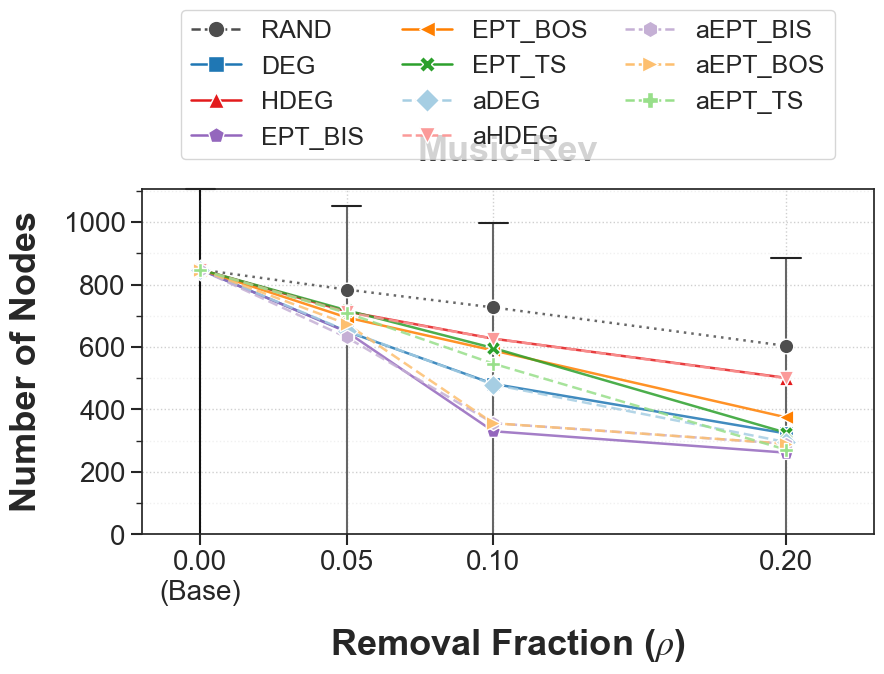

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.ticker import AutoMinorLocator

# ==========================================
# 1. Aesthetics & Comprehensive Strategy Configs
# ==========================================
sns.set_theme(style="white") 

# Grouped color scheme: standard=dark, adaptive=light/pastel
palette = {
    'RAND': '#4d4d4d',       # Gray
    
    'DEG': '#1f77b4',        # Dark Blue
    'aDEG': '#a6cee3',       # Light Blue
    
    'HDEG': '#e31a1c',       # Dark Red
    'aHDEG': '#fb9a99',      # Light Red
    
    'EPT_BIS': '#9467bd',    # Dark Purple
    'aEPT_BIS': '#c5b0d5',   # Light Purple
    
    'EPT_BOS': '#ff7f00',    # Dark Orange
    'aEPT_BOS': '#fdbf6f',   # Light Orange
    
    'EPT_TS': '#2ca02c',     # Dark Green
    'aEPT_TS': '#98df8a'     # Light Green
}

markers = {
    'RAND': 'o', 
    'DEG': 's', 'aDEG': 'D', 
    'HDEG': '^', 'aHDEG': 'v',
    'EPT_BIS': 'p', 'aEPT_BIS': 'h',
    'EPT_BOS': '<', 'aEPT_BOS': '>',
    'EPT_TS': 'X', 'aEPT_TS': 'P'
}

dashes = {
    'RAND': (1, 2), 
    'DEG': [], 'aDEG': (4, 2), 
    'HDEG': [], 'aHDEG': (4, 2),
    'EPT_BIS': [], 'aEPT_BIS': (4, 2),
    'EPT_BOS': [], 'aEPT_BOS': (4, 2),
    'EPT_TS': [], 'aEPT_TS': (4, 2)       
}

# All 11 targeted strategies
local_strategies = [
    'RAND', 'DEG', 'HDEG', 'EPT_BIS', 'EPT_BOS', 'EPT_TS',
    'aDEG', 'aHDEG', 'aEPT_BIS', 'aEPT_BOS', 'aEPT_TS'
]

# ==========================================
# 2. Data Filtering & Single Dataset Selection
# ==========================================
# Filter primary data
all_filtered_df = selected_df[
    (selected_df['community_config'] == 'ground_truth') &
    (selected_df['timestep'] == 25) &
    (selected_df['strategy'].isin(local_strategies))
].copy()

# Specify your target dataset name here. 
# Defaulting to the first available dataset in the dataframe if not explicitly specified.
# target_dataset = all_filtered_df['dataset'].unique()[1] 
target_dataset = 'Music-Rev'

plot_df = all_filtered_df[all_filtered_df['dataset'] == target_dataset].copy()

# Extract baseline percentages
baseline_pcts = empty_df.set_index('Unnamed: 0').iloc[0].to_dict()

# Reverse engineer capacity for this single dataset
sample_row = plot_df.iloc[0]
n0 = sample_row['remaining_nodes'] / (1 - sample_row['p'])

pct = baseline_pcts.get(target_dataset, 0)
abs_infected_base = n0 * (pct / 100.0)

# Build baseline rows for all 11 strategies
baseline_rows = []
for strategy in local_strategies:
    baseline_rows.append({
        'dataset': target_dataset,
        'strategy': strategy,
        'p': 0.0,
        'remaining_nodes': n0,
        'mean_infected': abs_infected_base,
        'community_config': 'ground_truth',
        'timestep': 25
    })

plot_df = pd.concat([plot_df, pd.DataFrame(baseline_rows)], ignore_index=True)

# ==========================================
# 3. Canvas Initialization (Single Panel)
# ==========================================
fig, ax = plt.subplots(figsize=(9, 7))

unique_ps = sorted(plot_df['p'].unique())

# Draw capacity trunks and T-caps
for p_val in unique_ps:
    sub_data = plot_df[plot_df['p'] == p_val]
    if not sub_data.empty:
        rem_nodes = sub_data['remaining_nodes'].iloc[0]
        line_color = '#111111' if p_val == 0.0 else '#666666'
        
        ax.vlines(x=p_val, ymin=0, ymax=rem_nodes, colors=line_color, linewidth=1.5, zorder=1, clip_on=False)
        ax.plot([p_val - 0.005, p_val + 0.005], [rem_nodes, rem_nodes], color='#222222', linewidth=1.5, zorder=1, clip_on=False)

# Draw trend lines and markers for all 11 strategies
for strategy in local_strategies:
    strat_data = plot_df[plot_df['strategy'] == strategy].sort_values('p')
    if not strat_data.empty:
        dash_style = dashes.get(strategy, [])
        
        line, = ax.plot(
            strat_data['p'], strat_data['mean_infected'], 
            color=palette[strategy], linewidth=1.8, alpha=0.85, zorder=3, clip_on=False
        )
        if len(dash_style) > 0:
            line.set_dashes(dash_style)
            
        ax.scatter(
            strat_data['p'], strat_data['mean_infected'], 
            color=palette[strategy], marker=markers[strategy], s=110,
            edgecolor='white', linewidth=1.0, alpha=1.0, zorder=4, clip_on=False
        )

# ==========================================
# 4. Layout, Formatting & Text Sizing
# ==========================================
# Labels and Title
ax.set_xlabel("Removal Fraction ($\\rho$)", fontsize=26, weight='bold', labelpad=15)
ax.set_ylabel("Number of Nodes", fontsize=26, weight='bold', labelpad=15)
ax.set_title(target_dataset, size=26, weight='bold', pad=20) 

# Gridlines
ax.grid(True, which='major', linestyle=':', alpha=0.6, color='#b0b0b0')
ax.yaxis.set_minor_locator(AutoMinorLocator(2)) 
ax.grid(True, which='minor', linestyle=':', alpha=0.3, color='#d0d0d0')

# Outer Spines bounding the canvas
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

# Tick Tuning
ax.tick_params(axis='both', which='major', labelsize=20, left=True, bottom=True, length=8, width=1.5)
ax.tick_params(axis='y', which='minor', left=True, length=4, width=1.0) 

# Horizontal Axis Ticks
ax.set_xticks([0.0, 0.05, 0.10, 0.20])
ax.set_xticklabels(['0.00\n(Base)', '0.05', '0.10', '0.20'], fontsize=20)
ax.set_xlim(-0.02, 0.23) 

# Vertical Axis Ceiling Cap
ax.set_ylim(bottom=0, top=n0)

# ==========================================
# 5. Legend Generation (Clean 3-Column Grid)
# ==========================================
legend_handles = [
    plt.Line2D(
        [0], [0], marker=markers[s], color=palette[s], markerfacecolor=palette[s], 
        markeredgecolor='white', markeredgewidth=1.0, markersize=12, linewidth=1.8,
        linestyle='--' if len(dashes[s]) > 0 else '-', label=s
    ) for s in local_strategies
]

# Set ncol=3 to handle 11 items cleanly above the single panel
ax.legend(
    handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, 1.05),    
    ncol=3, frameon=True, fontsize=18, columnspacing=1.5
)

plt.tight_layout()
plt.show()

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Isolate RAND data for the specific timestep
rand_df = selected_df[
    (selected_df['community_config'] == 'ground_truth') &
    (selected_df['timestep'] == 25) &
    (selected_df['strategy'] == 'RAND')
].copy()

# 2. Extract the baseline (p=0) infection percentages from empty_df
baseline_pcts = empty_df.set_index('Unnamed: 0').iloc[0].to_dict()

# 3. Calculate metrics
# Actual percentage of the surviving network that got infected
rand_df['actual_relative_pct'] = (rand_df['mean_infected'] / rand_df['remaining_nodes']) * 100

# Map the expected percentage (the p=0 baseline) 
rand_df['baseline_expected_pct'] = rand_df['dataset'].map(baseline_pcts)

# Calculate the "Extra Inhibitance" (Percentage points of infection prevented structurally)
rand_df['extra_inhibitance_pct'] = rand_df['baseline_expected_pct'] - rand_df['actual_relative_pct']

# Display a preview of the calculations
display(rand_df[['dataset', 'p', 'baseline_expected_pct', 'actual_relative_pct', 'extra_inhibitance_pct']].head(10))

,dataset,p,baseline_expected_pct,actual_relative_pct,extra_inhibitance_pct
2885,Algebra,0.05,25.876856,23.411852,2.465004
2963,Algebra,0.10,25.876856,21.915976,3.960880
3041,Algebra,0.20,25.876856,18.443879,7.432977
3119,Bars-Rev,0.05,46.526246,44.518626,2.007620
3197,Bars-Rev,0.10,46.526246,43.138878,3.387368
3275,Bars-Rev,0.20,46.526246,40.010384,6.515862
3353,contact-primary-school,0.05,1.003859,0.898091,0.105768
3431,contact-primary-school,0.10,1.003859,0.932266,0.071593
3509,contact-primary-school,0.20,1.003859,1.019529,-0.015670
3587,Geometry,0.05,69.739863,66.817122,2.922741


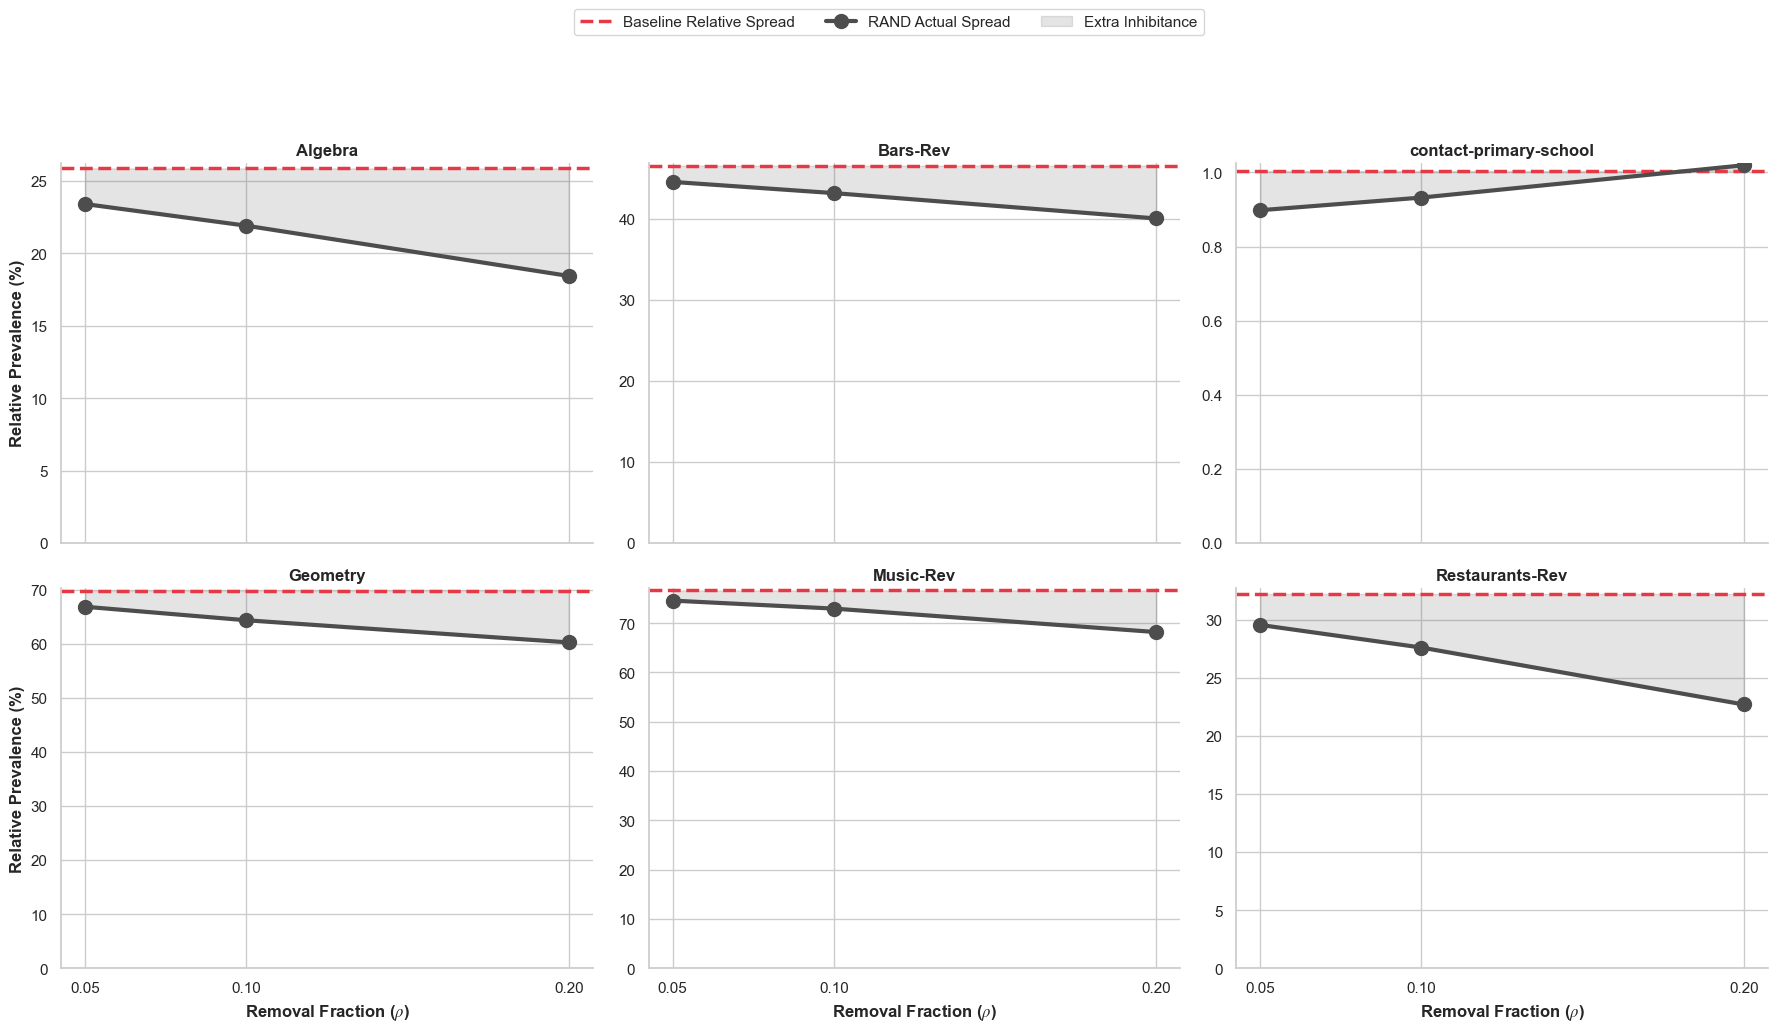

In [59]:
# Setup aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 14})

g = sns.FacetGrid(
    data=rand_df, 
    col='dataset', 
    col_wrap=3, 
    height=5.0, 
    aspect=1.2,
    sharey=False
)

def draw_inhibitance(data, **kwargs):
    ax = plt.gca()
    dataset = data['dataset'].iloc[0]
    baseline_val = data['baseline_expected_pct'].iloc[0]
    
    # 1. Draw the "Zero Extra Inhibitance" baseline (Expected if it just shrank)
    ax.axhline(
        y=baseline_val, 
        color='#e63946', 
        linestyle='--', 
        linewidth=2.5, 
        label='Baseline Relative Spread'
    )
    
    # 2. Draw the Actual Relative Spread for RAND
    ax.plot(
        data['p'], 
        data['actual_relative_pct'], 
        color='#4d4d4d', 
        marker='o', 
        linewidth=3, 
        markersize=10, 
        label='RAND Actual Spread'
    )
    
    # 3. Shade the gap (The "Extra" structural inhibitance)
    ax.fill_between(
        data['p'], 
        data['actual_relative_pct'], 
        baseline_val, 
        color='#4d4d4d', 
        alpha=0.15,
        label='Extra Inhibitance'
    )

g.map_dataframe(draw_inhibitance)

# Formatting
g.set_axis_labels("Removal Fraction ($\\rho$)", "Relative Prevalence (%)", weight='bold')
g.set_titles(col_template="{col_name}", weight='bold')

for ax in g.axes.flat:
    ax.set_xticks([0.05, 0.10, 0.20])
    ax.set_ylim(bottom=0)

# Add Legend
handles, labels = g.axes.flat[0].get_legend_handles_labels()
g.figure.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=True)

plt.tight_layout()
g.fig.subplots_adjust(top=0.88)
plt.show()

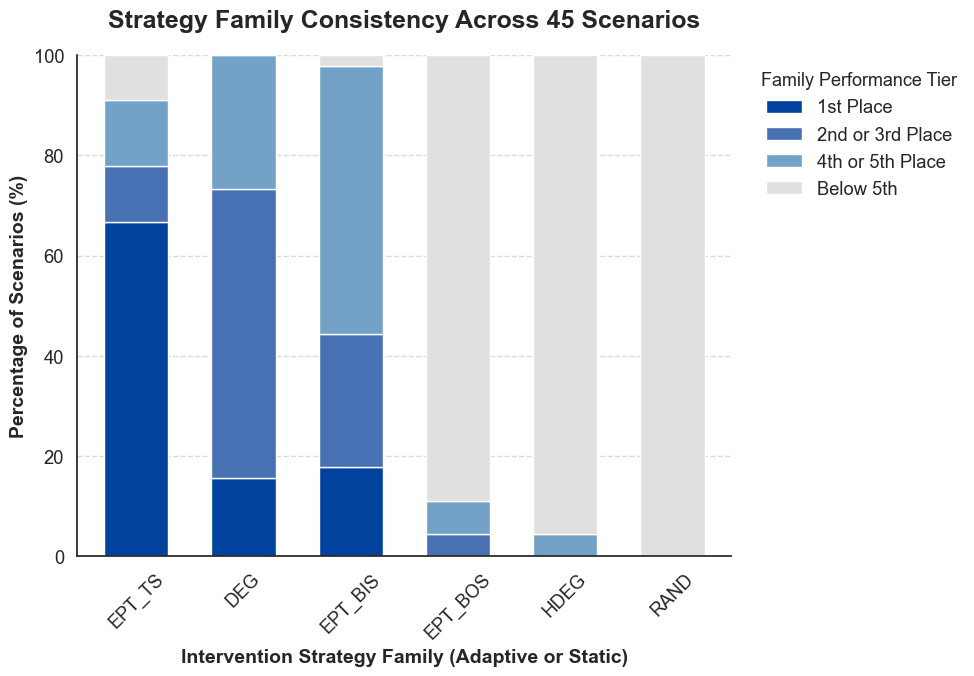

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter out 'contact-primary-school'
plot_df = selected_df[
    selected_df['dataset'] != 'contact-primary-school'
].copy()

# 2. Define what constitutes a unique "scenario"-
scenario_cols = ['dataset', 'p', 'community_config']

# 3. Average across `sim_run` repeats 
agg_df = plot_df.groupby(scenario_cols + ['strategy'])['mean_infected'].mean().reset_index()

# 4. Rank all individual strategies (1 to 10) within each scenario
agg_df['rank'] = agg_df.groupby(scenario_cols)['mean_infected'].rank(method='min', ascending=True)

# 5. Create a "Base Strategy" family column (strips the 'a' prefix if it exists)
def get_base_strategy(name):
    if name.startswith('a') and len(name) > 1:
        return name[1:]  # e.g., 'aEPT_TS' becomes 'EPT_TS'
    return name

agg_df['base_strategy'] = agg_df['strategy'].apply(get_base_strategy)

# 6. For each scenario, find the BEST (minimum) rank achieved by the family
family_df = agg_df.groupby(scenario_cols + ['base_strategy'])['rank'].min().reset_index()

# 7. Categorize the family's best rank into distinct tiers
def categorize_rank(r):
    if r == 1:
        return '1st Place'
    elif r <= 3:
        return '2nd or 3rd Place'
    elif r <= 5:
        return '4th or 5th Place'
    else:
        return 'Below 5th'

family_df['rank_category'] = family_df['rank'].apply(categorize_rank)

# 8. Count occurrences and convert to percentages
total_scenarios = len(family_df.groupby(scenario_cols)) # Still 45 scenarios
rank_counts = family_df.groupby(['base_strategy', 'rank_category']).size().unstack(fill_value=0)

# Ensure all columns exist
plot_cols = ['1st Place', '2nd or 3rd Place', '4th or 5th Place', 'Below 5th']
for col in plot_cols:
    if col not in rank_counts.columns:
        rank_counts[col] = 0

rank_pct = (rank_counts / total_scenarios) * 100

# 9. Sort strategy families so the most consistently good ones are on the left
rank_pct['Top_3_Total'] = rank_pct['1st Place'] + rank_pct['2nd or 3rd Place']
rank_pct = rank_pct.sort_values(by=['Top_3_Total', '1st Place'], ascending=[False, False])

# 10. Plotting the Stacked Bar Chart
sns.set_theme(style="white", font_scale=1.2)

colors = ['#00429d', '#4771b2', '#73a2c6', '#e0e0e0']

fig, ax = plt.subplots(figsize=(10, 7))

rank_pct[plot_cols].plot(
    kind='bar', 
    stacked=True, 
    color=colors, 
    ax=ax, 
    width=0.6, # Slightly narrower bars look better with fewer categories
    edgecolor='white',
    linewidth=1
)

# 11. Formatting for a scientific paper
ax.set_title(f'Strategy Family Consistency Across {total_scenarios} Scenarios', fontsize=18, weight='bold', pad=20)
ax.set_ylabel('Percentage of Scenarios (%)', fontsize=14, weight='bold')
ax.set_xlabel('Intervention Strategy Family (Adaptive or Static)', fontsize=14, weight='bold')

ax.set_ylim(0, 100)

ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(
    title='Family Performance Tier', 
    title_fontsize='13',
    bbox_to_anchor=(1.02, 1), 
    loc='upper left',
    frameon=False
)

plt.tight_layout()
plt.show()